In [1]:
import os
os.chdir(os.path.dirname(os.getcwd()))

In [2]:
import pandas as pd
'''
19 years (2006-2025) -> 6935 days
  yellow       1474 rows
  amber         448 rows
  red            20 rows

1942 / 6935
approx 29% warnings

200000 days
Yellow: 42509
Amber: 12920
Red: 577
'''
# Get total historical flood warnings (excludes duplicate same day warnings (same day, different area))
total = 0
warning_rows = []
warnings = ['yellow', 'amber', 'red']
for warning in warnings:
    csv_path = f"warning/{warning}_warnings.csv"
    df = pd.read_csv(csv_path)
    rows = len(df)
    print(f"  {warning:<10} {rows:>6} rows")
    total += rows
    warning_rows.append(rows)
print(f"  {'TOTAL':<10} {total:>6} rows\n")

  yellow       1474 rows
  amber         448 rows
  red            20 rows
  TOTAL        1942 rows



Crossing thresholds:
  [yellow] no_warning_threshold = 0.0456
  [amber] no_warning_threshold = 0.0456
  [red] no_warning_threshold = 0.0456


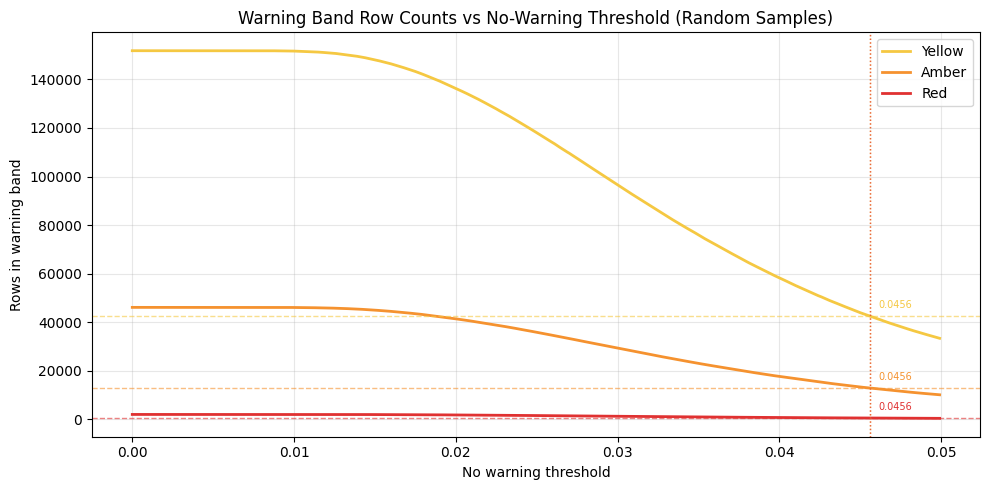

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load warning data and count how many rows are in each warning band for the random samples
warnings = ['yellow', 'amber', 'red']
warning_rows = []
for warning in warnings:
    df = pd.read_csv(f"warning/{warning}_warnings.csv")
    warning_rows.append(len(df))
total = sum(warning_rows)

df_sample = pd.read_csv("warning/samples/random_samples.csv")

# Sweep no_warning_threshold 
thresholds = np.arange(0, 0.05, 0.0001)
colors = {'yellow': '#f5c842', 'amber': '#f5922f', 'red': '#e03131'}
threshold_lines = {'yellow': 42509, 'amber': 12920, 'red': 577}

results = {w: [] for w in warnings}

for t in thresholds:
    df_filtered = df_sample.loc[df_sample['impact'] > t].copy()
    for i, w in enumerate(warnings):
        p_start = t + (sum(warning_rows[:i])   / total) * (1 - t)
        p_end   = t + (sum(warning_rows[:i+1]) / total) * (1 - t)
        p_start_rescaled = (p_start - t) / (1 - t)
        p_end_rescaled   = (p_end   - t) / (1 - t)
        q_start = df_filtered['impact'].quantile(p_start_rescaled)
        q_end   = df_filtered['impact'].quantile(p_end_rescaled)
        rows_in_range = len(df_filtered.loc[(df_filtered['impact'] > q_start) & (df_filtered['impact'] <= q_end)])
        results[w].append(rows_in_range)

fig, ax = plt.subplots(figsize=(10, 5))

for w in warnings:
    ax.plot(thresholds, results[w], label=w.capitalize(), color=colors[w], linewidth=2)

crossing_thresholds = {}
for w, target in threshold_lines.items():
    ax.axhline(y=target, color=colors[w], linewidth=1, linestyle='--', alpha=0.6)

    curve = np.array(results[w])
    diffs = curve - target
    cross_idx = np.where(np.diff(np.sign(diffs)))[0]

    if len(cross_idx) > 0:
        idx = cross_idx[0]
        x0, x1 = thresholds[idx], thresholds[idx + 1]
        y0, y1 = curve[idx], curve[idx + 1]
        x_cross = x0 + (target - y0) * (x1 - x0) / (y1 - y0)
        crossing_thresholds[w] = x_cross

        ax.axvline(x=x_cross, color=colors[w], linewidth=1, linestyle=':', alpha=0.6)
        ax.annotate(
            f'{x_cross:.4f}',
            xy=(x_cross, target),
            xytext=(6, 6),
            textcoords='offset points',
            fontsize=7,
            color=colors[w],
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none')
        )

print("Crossing thresholds:")
for w, x_cross in crossing_thresholds.items():
    print(f"  [{w}] no_warning_threshold = {x_cross:.4f}")

ax.set_title('Warning Band Row Counts vs No-Warning Threshold (Random Samples)')
ax.set_xlabel('No warning threshold')
ax.set_ylabel('Rows in warning band')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
no_warning_threshold = 0.0456

df = pd.read_csv("warning/samples/random_samples.csv")
total_rows = len(df)
print(f"Count: {total_rows}")

df = df.loc[df['impact'] > no_warning_threshold]
no_warning_rows = total_rows - len(df)
print(f"  [no warning] impact: 0.0000 - {no_warning_threshold:.4f} ({no_warning_rows} rows)")

for i in range(3):
    p_start = no_warning_threshold + (sum(warning_rows[:i]) / total) * (1 - no_warning_threshold)
    p_end = no_warning_threshold + (sum(warning_rows[:i+1]) / total) * (1 - no_warning_threshold)
    p_start_rescaled = (p_start - no_warning_threshold) / (1 - no_warning_threshold)
    p_end_rescaled = (p_end - no_warning_threshold) / (1 - no_warning_threshold)
    q_start = df['impact'].quantile(p_start_rescaled)
    q_end = df['impact'].quantile(p_end_rescaled)
    rows_in_range = len(df.loc[(df['impact'] > q_start) & (df['impact'] <= q_end)])
    print(f"  [{warnings[i]}] {p_start:.4%} - {p_end:.4%}  ->  impact: {q_start:.4f} - {q_end:.4f} ({rows_in_range} rows)")

Count: 200000
  [no warning] impact: 0.0000 - 0.0456 (144048 rows)
  [yellow] 4.5600% - 77.0000%  ->  impact: 0.0456 - 0.0725 (42467 rows)
  [amber] 77.0000% - 99.0171%  ->  impact: 0.0725 - 0.2345 (12907 rows)
  [red] 99.0171% - 100.0000%  ->  impact: 0.2345 - 0.9280 (577 rows)


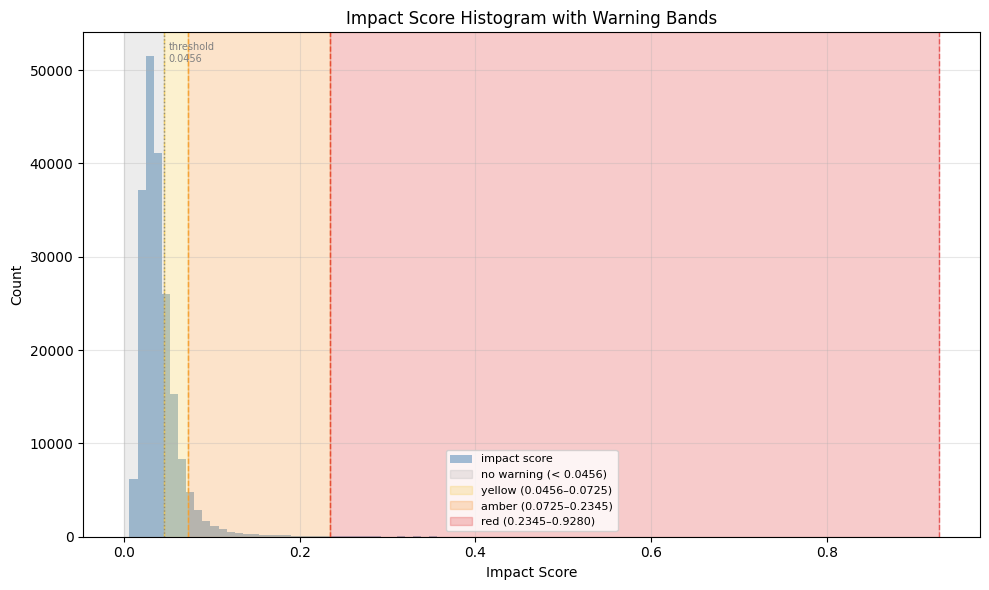

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

no_warning_threshold = 0.0456  # consistent with calibrated value
warnings = ['yellow', 'amber', 'red']

# Load historical counts
warning_rows = []
total = 0
for w in warnings:
    df = pd.read_csv(f"warning/{w}_warnings.csv")
    warning_rows.append(len(df))
    total += len(df)

colors = {'yellow': '#f5c842', 'amber': '#f5922f', 'red': '#e03131'}

df = pd.read_csv("warning/samples/random_samples.csv")
df_filtered = df.loc[df['impact'] > no_warning_threshold]

# Compute band boundaries as relative quantile positions within filtered data
# Each band gets a share proportional to its historical warning count
impact_bands = []
for i in range(3):
    rel_start = sum(warning_rows[:i]) / total      # relative position within filtered data
    rel_end   = sum(warning_rows[:i+1]) / total
    q_start = df_filtered['impact'].quantile(rel_start)
    q_end   = df_filtered['impact'].quantile(rel_end)
    impact_bands.append((q_start, q_end))

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(df['impact'], bins=100, color='steelblue', alpha=0.5, label='impact score')

ax.axvspan(0, no_warning_threshold, alpha=0.15, color='gray', label=f'no warning (< {no_warning_threshold})')

for w, (q_start, q_end) in zip(warnings, impact_bands):
    ax.axvspan(q_start, q_end, alpha=0.25, color=colors[w], label=f'{w} ({q_start:.4f}–{q_end:.4f})')
    ax.axvline(x=q_start, color=colors[w], linewidth=1, linestyle='--', alpha=0.7)
    ax.axvline(x=q_end,   color=colors[w], linewidth=1, linestyle='--', alpha=0.7)

ax.axvline(x=no_warning_threshold, color='gray', linewidth=1, linestyle=':', alpha=0.8)
ax.text(no_warning_threshold + 0.005, 0.98, f'threshold\n{no_warning_threshold}',
        fontsize=7, color='gray', transform=ax.get_xaxis_transform(), va='top')

ax.set_title('Impact Score Histogram with Warning Bands')
ax.set_xlabel('Impact Score')
ax.set_ylabel('Count')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()